In [1]:
#  Imports
import pandas as pd
import joblib
import json
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import xgboost as xgb
import warnings
import numpy as np
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import brier_score_loss
import sys, os

# Add project / to path , try to change to ../src in path below if running this creates error 
sys.path.insert(0, os.path.abspath('../'))

from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

from src.utils.config import (
    PATHS, TARGET_COL, RANDOM_STATE,
    XGB_CATEGORICAL_COLS, CATEGORICAL_FEATURES, CONTINUOUS_FEATURES, LEAKAGE_COLUMNS
)
from src.utils.evaluation import (
    report_auc, report_auc_all, model_comparison_table,
    fit_platt_scaling, fit_isotonic,
    apply_platt, apply_isotonic,
    hosmer_lemeshow_test,
    plot_calibration_raw, plot_calibration_comparison,plot_roc_comparison,
    lr_coefficient_table, xgb_importance_table, plot_feature_importance,
)


In [19]:
final_dir = PATHS['final_dir']

# --- LR path: WoE-transformed features ---
X_train_woe = pd.read_parquet(final_dir / 'X_train_woe_t2.parquet')
X_val_woe   = pd.read_parquet(final_dir / 'X_val_woe_t2.parquet')
X_oot_woe   = pd.read_parquet(final_dir / 'X_oot_woe_t2.parquet')

# --- XGBoost path: raw features ---
X_train = pd.read_parquet(final_dir / 'X_train_v2.parquet')
X_val   = pd.read_parquet(final_dir / 'X_val_v2.parquet')
X_oot   = pd.read_parquet(final_dir / 'X_oot_v2.parquet')

# --- Shared target ---
y_train = pd.read_parquet(final_dir / 'y_train_v2.parquet').squeeze()
y_val   = pd.read_parquet(final_dir / 'y_val_v2.parquet').squeeze()
y_oot   = pd.read_parquet(final_dir / 'y_oot_v2.parquet').squeeze()

# --- WoE artefacts (for production later) ---
woe_rules = joblib.load(final_dir / 'woe_rules_t2.joblib')
selected_vars = joblib.load(final_dir / 'selected_vars_t2.joblib')

print(f"Logistic Regression features (WoE):  {X_train_woe.shape[1]}")
print(f"XGBoost features (raw): {X_train.shape[1]}")
print(f"Train: {len(y_train):,} | Val: {len(y_val):,} | OOT: {len(y_oot):,}")
print(f"Default rate — Train: {y_train.mean():.2%} | Val: {y_val.mean():.2%} | OOT: {y_oot.mean():.2%}")


Logistic Regression features (WoE):  14
XGBoost features (raw): 36
Train: 109,035 | Val: 16,348 | OOT: 19,646
Default rate — Train: 15.65% | Val: 13.48% | OOT: 15.16%


# LOGISTIC REGRESSION

In [20]:

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)
lr_model.fit(X_train_woe, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [21]:

# Predict probabilities
lr_probs_train = lr_model.predict_proba(X_train_woe)[:, 1]
lr_probs_val   = lr_model.predict_proba(X_val_woe)[:, 1]
lr_probs_oot   = lr_model.predict_proba(X_oot_woe)[:, 1]

lr_auc_train = roc_auc_score(y_train, lr_probs_train)
lr_auc_val = roc_auc_score(y_val, lr_probs_val)
lr_auc_oot = roc_auc_score(y_oot, lr_probs_oot)

lr_aucs = report_auc_all(
    y_train, lr_probs_train,
    y_val, lr_probs_val,
    y_oot, lr_probs_oot,
    model_name="Logistic Regression"
)



--- Logistic Regression Performance ---
  Train AUC: 0.6778 | Gini: 0.3556
  Val   AUC: 0.7024 | Gini: 0.4047
  OOT   AUC: 0.6908 | Gini: 0.3817


In [22]:
# 5-fold stratified CV on training data to check stability.


# %%
print("\n--- 5-Fold Stratified Cross-Validation (LR) ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv_scores = cross_val_score(lr_model, X_train_woe, y_train, cv=cv, scoring='roc_auc')

lr_cv = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    X_train_woe, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
)
print(f"\nLR 5-fold CV AUC: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")
print(f"  Folds: {[f'{x:.4f}' for x in lr_cv]}")



--- 5-Fold Stratified Cross-Validation (LR) ---

LR 5-fold CV AUC: 0.6774 ± 0.0050
  Folds: ['0.6814', '0.6812', '0.6808', '0.6686', '0.6749']


In [23]:
lr_coef_df = lr_coefficient_table(lr_model, X_train_woe.columns.tolist())
print("\n--- LR Coefficients (Tree based binning) ---")
print(lr_coef_df.to_string(index=False))


--- LR Coefficients (Tree based binning) ---
                              Feature  Coefficient
                     LoanDuration_woe     1.462437
                 VerificationType_woe    -1.375869
                CreditScoreEeMini_woe     1.117793
                              Age_woe     0.758944
                        Education_woe    -0.679203
                           Amount_woe     0.628205
                HomeOwnershipType_woe    -0.564348
     PreviousRepaymentsBeforeLoan_woe     0.541531
                   loan_to_income_woe     0.393795
EmploymentDurationCurrentEmployer_woe    -0.369734
                 LiabilitiesTotal_woe     0.338502
  AmountOfPreviousLoansBeforeLoan_woe     0.244433
                NewCreditCustomer_woe    -0.192470
              ExistingLiabilities_woe    -0.130222


# XGBOOST

In [3]:
# HOTFIX : Convert string categoricals to pandas Categorical dtype for XGBoost
cat_for_xgb = [c for c in XGB_CATEGORICAL_COLS if c in X_train]

X_train_xgb = X_train
X_val_xgb = X_val
X_oot_xgb = X_oot

# HOTFIX : Convert categoricals to integer codes 
for col in cat_for_xgb:
    for df_part in [X_train_xgb, X_val_xgb, X_oot_xgb]:
        df_part[col] = df_part[col].astype(str).astype('category').cat.codes.replace(-1, np.nan)

# This is to handle class imbalance as we observed in target creation and very common in credit risk to have imbalanced class since there are less defaults generally
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

print("\n--- Training XGBoost Baseline ---")
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,        
    max_depth=5,               
    scale_pos_weight=imbalance_ratio,
    early_stopping_rounds=50,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=False
)
print(f"  Best iteration: {xgb_model.best_iteration}")





--- Training XGBoost Baseline ---
  Best iteration: 100


In [4]:
# Evaluate XGBoost
xgb_probs_train = xgb_model.predict_proba(X_train_xgb)[:, 1]
xgb_probs_val = xgb_model.predict_proba(X_val_xgb)[:, 1]
xgb_probs_oot = xgb_model.predict_proba(X_oot_xgb)[:, 1]

# Report
xgb_aucs = report_auc_all(
    y_train, xgb_probs_train,
    y_val, xgb_probs_val,
    y_oot, xgb_probs_oot,
    model_name="XGBoost"
)


--- XGBoost Performance ---
  Train AUC: 0.7396 | Gini: 0.4792
  Val   AUC: 0.7036 | Gini: 0.4072
  OOT   AUC: 0.6731 | Gini: 0.3462


In [5]:

xgb_cv_model = XGBClassifier(
    n_estimators=xgb_model.best_iteration,  
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=imbalance_ratio,
    enable_categorical=True,
    tree_method='hist',
    eval_metric='auc',
    random_state=RANDOM_STATE,
    verbosity=0,
)

xgb_cv = cross_val_score(
    xgb_cv_model,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
)
print(f"\nXGB 5-fold CV AUC: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")
print(f"  Folds: {[f'{x:.4f}' for x in xgb_cv]}")


XGB 5-fold CV AUC: 0.7060 ± 0.0059
  Folds: ['0.7108', '0.7045', '0.7143', '0.6973', '0.7034']


In [7]:
xgb_imp_df = xgb_importance_table(xgb_model, X_train.columns.tolist())
print("\n--- XGBoost Feature Importance (Gain) ---")
print(xgb_imp_df.head(20).to_string(index=False))


--- XGBoost Feature Importance (Gain) ---
                          Feature  Importance
                NewCreditCustomer    0.090169
                CreditScoreEeMini    0.086175
                 VerificationType    0.061161
                     LoanDuration    0.055773
                        Education    0.047280
                              Age    0.046712
EmploymentDurationCurrentEmployer    0.044295
                HomeOwnershipType    0.041429
     PreviousRepaymentsBeforeLoan    0.032096
                 EmploymentStatus    0.031565
                           Amount    0.030123
                   approval_ratio    0.030018
PreviousEarlyRepaymentsBefoleLoan    0.029897
                        UseOfLoan    0.029088
              ExistingLiabilities    0.027749
                    MaritalStatus    0.024090
  AmountOfPreviousLoansBeforeLoan    0.023495
                   NrOfDependants    0.022392
                   WorkExperience    0.021769
            ApplicationSignedHour    

# Compare both models


MODEL COMPARISON (OOT Performance)
                    Model  Train AUC  Val AUC  OOT AUC  Train Gini  Val Gini  OOT Gini  CV AUC (mean)  CV AUC (std)
Logistic Regression (WoE)   0.677794 0.702374 0.690842    0.355588  0.404748  0.381684       0.677372      0.005015
          XGBoost (Tuned)   0.739585 0.703605 0.673091    0.479169  0.407210  0.346181       0.706046      0.005937

--- AUC Interpretation ---


Discriminatory Power : AUC
AUC measures the model's ability to rank-order borrowers by default risk. It essentially shows the probability. 

Relative Lift
Gini value higher are better.
It shows better our model does than random guessing, it shows what added value our model brings in telling if a customer is good or badd




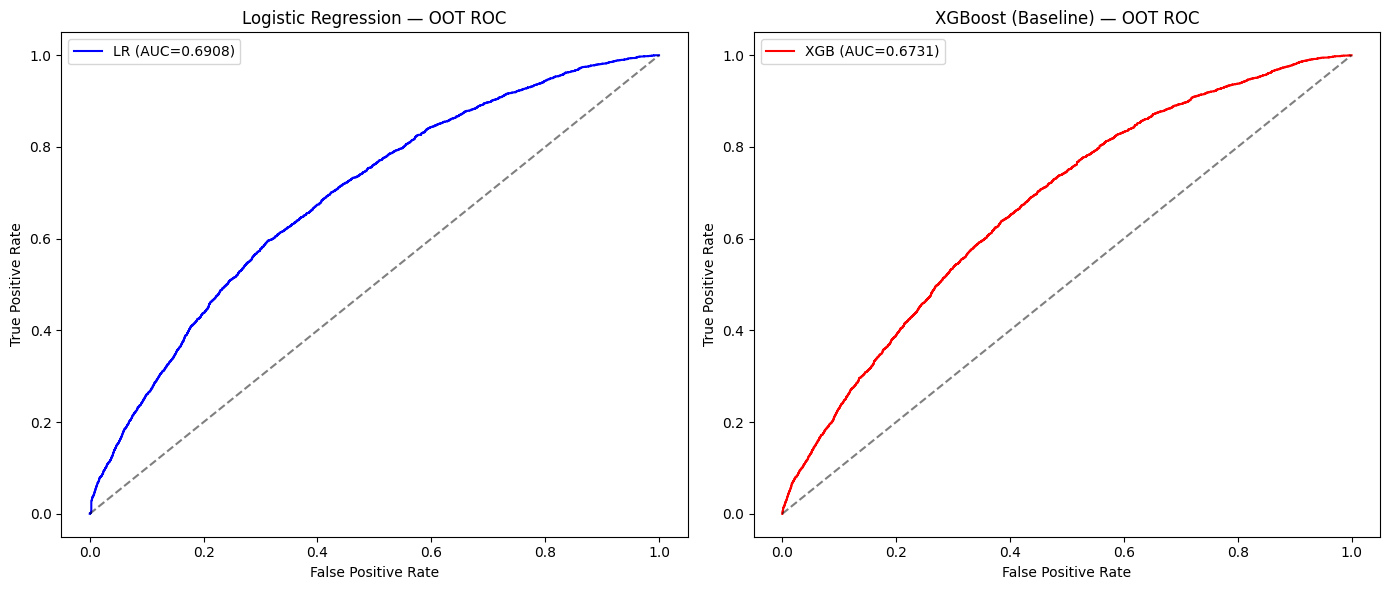

In [25]:

# --- 8.1 Side-by-side comparison ---
print("\n" + "=" * 65)
print("MODEL COMPARISON (OOT Performance)")
print("=" * 65)

comparison = model_comparison_table(lr_aucs, xgb_aucs, lr_cv, xgb_cv)
print(comparison.to_string(index=False))
print("\n--- AUC Interpretation ---")
print("""

Discriminatory Power : AUC
AUC measures the model's ability to rank-order borrowers by default risk. It essentially shows the probability. 

Relative Lift
Gini value higher are better.
It shows better our model does than random guessing, it shows what added value our model brings in telling if a customer is good or badd

"""
)




fig = plot_roc_comparison(y_oot, lr_probs_oot, xgb_probs_oot, lr_aucs['oot'], xgb_aucs['oot'])
fig.savefig(PATHS['reports_dir'] / 'figures' / 'roc_comparison.png', dpi=150, bbox_inches='tight')

In [26]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [27]:
def objective(trial):
    params = {
        # --- Tree structure ---
        "max_depth":          trial.suggest_int("max_depth", 3, 7),
        "min_child_weight":   trial.suggest_int("min_child_weight", 5, 100),

        # --- Learning rate & ensemble size ---
        "n_estimators":       trial.suggest_int("n_estimators", 200, 1000, step=100),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.15, log=True),

        # --- Stochastic subsampling (reduces overfitting) ---
        "subsample":          trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel":  trial.suggest_float("colsample_bylevel", 0.5, 1.0),

        # --- L1 / L2 regularisation ---
        "reg_alpha":          trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),

        # --- Fixed settings (carry over from baseline model) ---
        "scale_pos_weight":   imbalance_ratio,
        "eval_metric":        "auc",
        "tree_method":        "hist",
        "random_state":       RANDOM_STATE,
        "verbosity":          0,
    }

    model = xgb.XGBClassifier(**params, early_stopping_rounds=30)
    model.fit(
        X_train_xgb, y_train,
        eval_set=[(X_val_xgb, y_val)],
        verbose=False,
    )
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val_xgb)[:, 1])
    return val_auc


N_TRIALS = 75   # increase to 150+ for production; ~75 is a good demo run

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="xgb_pd_model",
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest Val AUC : {study.best_value:.4f}")
print(f"Best params  : {study.best_params}")

  0%|          | 0/75 [00:00<?, ?it/s]


Best Val AUC : 0.7113
Best params  : {'max_depth': 4, 'min_child_weight': 72, 'n_estimators': 600, 'learning_rate': 0.037169889612424456, 'subsample': 0.6500873355832663, 'colsample_bytree': 0.8812829080304144, 'colsample_bylevel': 0.6517444731061759, 'reg_alpha': 2.1690404913938406, 'reg_lambda': 0.9462584009955614}


In [29]:
best_params = study.best_params.copy()

xgb_tuned = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=imbalance_ratio,
    eval_metric="auc",
    tree_method="hist",
    random_state=RANDOM_STATE,
    verbosity=0,
    enable_categorical=True
)
xgb_tuned.fit(X_train_xgb, y_train, eval_set=[(X_val_xgb, y_val)],verbose=False)

print(f"Tuned XGBoost trained on {len(y_train):,} rows.")

Tuned XGBoost trained on 109,035 rows.


# Compare XGboost baseline vs Tuned

In [30]:
xgb_tuned_probs_train = xgb_tuned.predict_proba(X_train_xgb)[:, 1]
xgb_tuned_probs_val   = xgb_tuned.predict_proba(X_val_xgb)[:, 1]
xgb_tuned_probs_oot   = xgb_tuned.predict_proba(X_oot_xgb)[:, 1]


xgb_tuned_aucs = report_auc_all(
    y_train, xgb_tuned_probs_train,
    y_val,   xgb_tuned_probs_val,
    y_oot,   xgb_tuned_probs_oot,
    model_name="XGBoost Tuned",
)

# Quick side-by-side summary
print("\n" + "=" * 55)
print(f"{'Metric':<20} {'Baseline':>15} {'Tuned':>15}")
print("=" * 55)
for split in ['train', 'val', 'oot']:
    base_auc  = xgb_aucs[split]
    tuned_auc = xgb_tuned_aucs[split]
    delta     = tuned_auc - base_auc
    print(f"AUC {split.upper():<15} {base_auc:>15.4f} {tuned_auc:>15.4f}  (Δ {delta:+.4f})")
print("-" * 55)
for split in ['train', 'val', 'oot']:
    base_gini  = 2 * xgb_aucs[split]  - 1
    tuned_gini = 2 * xgb_tuned_aucs[split] - 1
    print(f"Gini {split.upper():<14} {base_gini:>15.4f} {tuned_gini:>15.4f}")
print("=" * 55)


--- XGBoost Tuned Performance ---
  Train AUC: 0.7514 | Gini: 0.5028
  Val   AUC: 0.7101 | Gini: 0.4201
  OOT   AUC: 0.6878 | Gini: 0.3756

Metric                      Baseline           Tuned
AUC TRAIN                    0.7396          0.7514  (Δ +0.0118)
AUC VAL                      0.7036          0.7101  (Δ +0.0065)
AUC OOT                      0.6731          0.6878  (Δ +0.0147)
-------------------------------------------------------
Gini TRAIN                   0.4792          0.5028
Gini VAL                     0.4072          0.4201
Gini OOT                     0.3462          0.3756


Still top performing is logistic regression based on AUC oot values but now performance is faily close between Logisitc vs Tuned XGBoost

- Logistic : AUC oot ~ 0.690842
- XGboost baseline : AUC oot ~ 0.6731
- XGboost Tuned : AUC oot ~ 0.6878